# Social Media, Health Information, and Trust
## Exploratory analysis of survey responses

This notebook analyzes a short survey about how students use social media, how often they encounter health-related content, and how much they trust different health information sources.

The analysis focuses on three parts:
- demographic and usage patterns
- trust in health information sources
- themes from the open-ended response

Because the dataset contains only 12 responses, the goal is descriptive exploration rather than statistical inference.

In [26]:
from collections import Counter
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Libraries imported successfully.")

Libraries imported successfully.


## Load and clean the survey data

The raw export includes scoring and feedback columns from the survey form. For this analysis, only the main response columns are used.

In [27]:
data_path = Path("Blank Quiz.csv")
df_raw = pd.read_csv(data_path)
df_raw.columns = [re.sub(r"\s+", " ", column).strip() for column in df_raw.columns]

question_map = {
    "What is your age range?": "age_range",
    "What is your gender?": "gender",
    "What is your academic year": "academic_year",
    "How often do you use social media?": "social_media_use",
    "Which platforms do you use most frequently?": "platforms",
    "How often do you encounter health-related content on social media?": "health_content_frequency",
    "I trust doctors and healthcare professionals.": "trust_doctors",
    "I trust public health agencies (e.g., CDC, WHO.)": "trust_public_health",
    "I trust hospitals and healthcare systems.": "trust_hospitals",
    "I trust government leadership in making health-related decisions.": "trust_government",
    "Information from health professionals is more reliable than social media.": "health_professionals_more_reliable",
    "In your own words, how does social media influence your trust in health information?": "free_text",
}

analysis_df = df_raw[list(question_map.keys())].rename(columns=question_map).copy()
trust_cols = [
    "trust_doctors",
    "trust_public_health",
    "trust_hospitals",
    "trust_government",
    "health_professionals_more_reliable",
]
analysis_df["composite_trust"] = analysis_df[trust_cols].mean(axis=1)

print(f"Rows analyzed: {analysis_df.shape[0]}")
print(f"Columns used in analysis: {analysis_df.shape[1]}")
display(analysis_df.head())
display(analysis_df.isna().sum().to_frame("missing_values"))

Rows analyzed: 12
Columns used in analysis: 13


,age_range,gender,academic_year,social_media_use,platforms,health_content_frequency,trust_doctors,trust_public_health,trust_hospitals,trust_government,health_professionals_more_reliable,free_text,composite_trust
0,24+,Male,Senior,1-2 hours,Tiktok;YouTube;Facebook,Often,5,2,4,3,4,NaN,3.6
1,18-20,Male,Freshman,1-2 hours,Tiktok;Instagram;YouTube,Often,5,5,5,2,5,Social Media give a microphone to any famous p...,4.4
2,18-20,Male,Sophomore,3-4 hours,Tiktok;Instagram;YouTube,Sometimes,5,4,2,1,5,NaN,3.4
3,18-20,Female,Sophomore,Less than 1 hour per day,Tiktok,Often,4,3,2,1,4,It doesn't. I always find myself very skeptica...,2.8
4,21-23,Male,Junior,3-4 hours,Tiktok;Instagram,Sometimes,4,4,4,2,4,NaN,3.6


,missing_values
age_range,0
gender,0
academic_year,0
social_media_use,0
platforms,0
health_content_frequency,0
trust_doctors,0
trust_public_health,0
trust_hospitals,0
trust_government,0


## Quick dataset snapshot

The sample is small, but it still reveals useful descriptive patterns about who responded and how they use social media.

In [28]:
summary = pd.DataFrame({
    "metric": [
        "responses",
        "age_groups",
        "genders",
        "academic_years",
        "social_media_usage_levels",
        "health_content_frequency_levels",
        "open_text_responses",
    ],
    "value": [
        len(analysis_df),
        analysis_df["age_range"].nunique(),
        analysis_df["gender"].nunique(),
        analysis_df["academic_year"].nunique(),
        analysis_df["social_media_use"].nunique(),
        analysis_df["health_content_frequency"].nunique(),
        analysis_df["free_text"].notna().sum(),
    ],
})
display(summary)

print("Average composite trust score:", round(analysis_df["composite_trust"].mean(), 2))
print("Median composite trust score:", round(analysis_df["composite_trust"].median(), 2))
print("Average trust by item:")
display(analysis_df[trust_cols].mean().sort_values(ascending=False).to_frame("mean_score").round(2))

,metric,value
0,responses,12
1,age_groups,3
2,genders,2
3,academic_years,4
4,social_media_usage_levels,4
5,health_content_frequency_levels,3
6,open_text_responses,6


Average composite trust score: 3.68
Median composite trust score: 3.6
Average trust by item:


,mean_score
trust_doctors,4.58
health_professionals_more_reliable,4.50
trust_public_health,3.92
trust_hospitals,3.58
trust_government,1.83


## Demographic composition

These charts summarize the age range, gender, and academic year of the respondents.

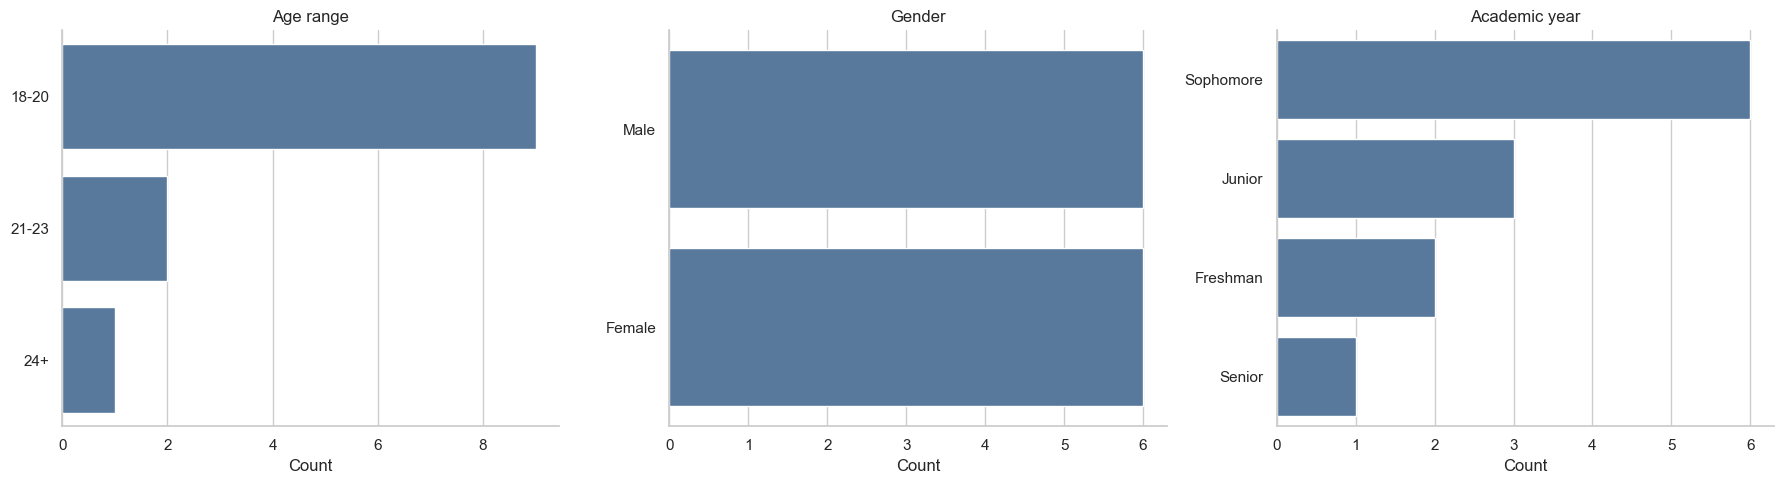

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
demographic_specs = [
    ("age_range", "Age range"),
    ("gender", "Gender"),
    ("academic_year", "Academic year"),
]

for ax, (column, title) in zip(axes, demographic_specs):
    order = analysis_df[column].value_counts().index
    sns.countplot(data=analysis_df, y=column, order=order, ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

## Social media use and exposure to health content

This section looks at how much time respondents spend on social media, how often they encounter health-related content, and which platforms appear most often.

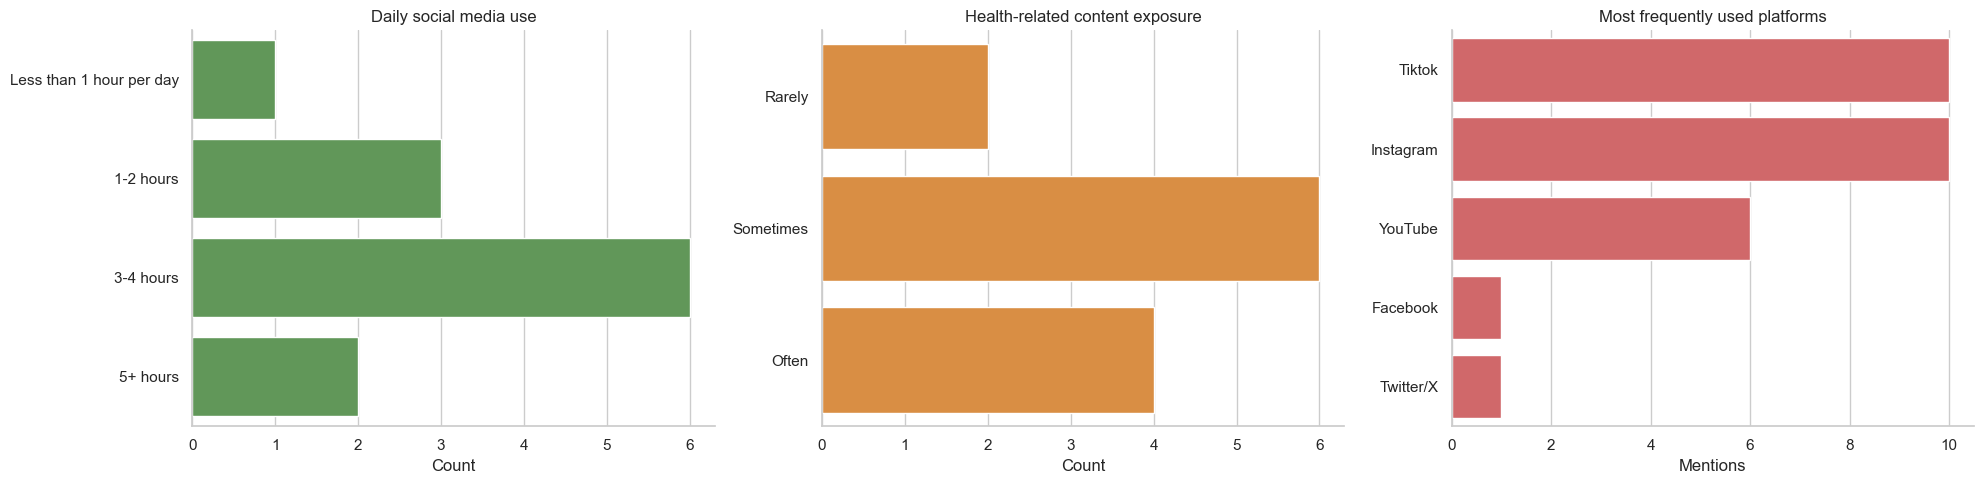

In [30]:
platform_counts = (
    analysis_df["platforms"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
usage_order = ["Less than 1 hour per day", "1-2 hours", "3-4 hours", "5+ hours"]
exposure_order = ["Rarely", "Sometimes", "Often"]

sns.countplot(data=analysis_df, y="social_media_use", order=[item for item in usage_order if item in analysis_df["social_media_use"].unique()], ax=axes[0], color="#59A14F")
axes[0].set_title("Daily social media use")
axes[0].set_xlabel("Count")
axes[0].set_ylabel("")

sns.countplot(data=analysis_df, y="health_content_frequency", order=[item for item in exposure_order if item in analysis_df["health_content_frequency"].unique()], ax=axes[1], color="#F28E2B")
axes[1].set_title("Health-related content exposure")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

sns.barplot(x=platform_counts.values, y=platform_counts.index, ax=axes[2], color="#E15759")
axes[2].set_title("Most frequently used platforms")
axes[2].set_xlabel("Mentions")
axes[2].set_ylabel("")

plt.tight_layout()
plt.show()

## Trust in health information

The Likert-scale questions provide the core quantitative signal in the survey. The chart below compares the average trust score for each item.

,mean,std,min,max
Doctors and healthcare professionals,4.58,0.51,4.0,5.0
Health professionals are more reliable,4.50,0.52,4.0,5.0
Public health agencies,3.92,0.79,2.0,5.0
Hospitals and healthcare systems,3.58,1.00,2.0,5.0
Government leadership,1.83,0.72,1.0,3.0


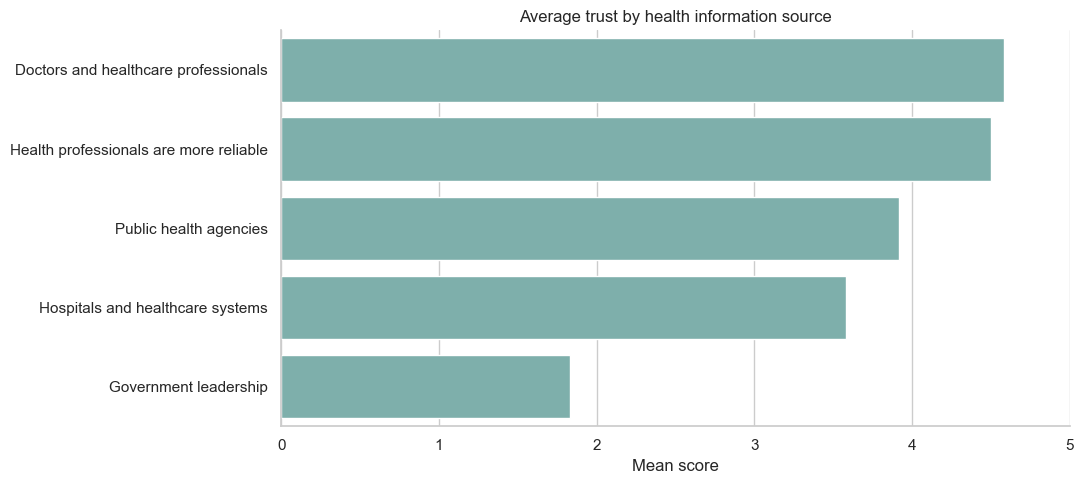

In [31]:
trust_labels = {
    "trust_doctors": "Doctors and healthcare professionals",
    "trust_public_health": "Public health agencies",
    "trust_hospitals": "Hospitals and healthcare systems",
    "trust_government": "Government leadership",
    "health_professionals_more_reliable": "Health professionals are more reliable",
}

trust_summary = (
    analysis_df[trust_cols]
    .agg(["mean", "std", "min", "max"])
    .T
    .rename(index=trust_labels)
    .sort_values("mean", ascending=False)
)
display(trust_summary.round(2))

fig, ax = plt.subplots(figsize=(11, 5))
trust_plot = trust_summary.reset_index().rename(columns={"index": "item"})
sns.barplot(data=trust_plot, x="mean", y="item", ax=ax, color="#76B7B2")
ax.set_title("Average trust by health information source")
ax.set_xlabel("Mean score")
ax.set_ylabel("")
ax.set_xlim(0, 5)

plt.tight_layout()
plt.show()

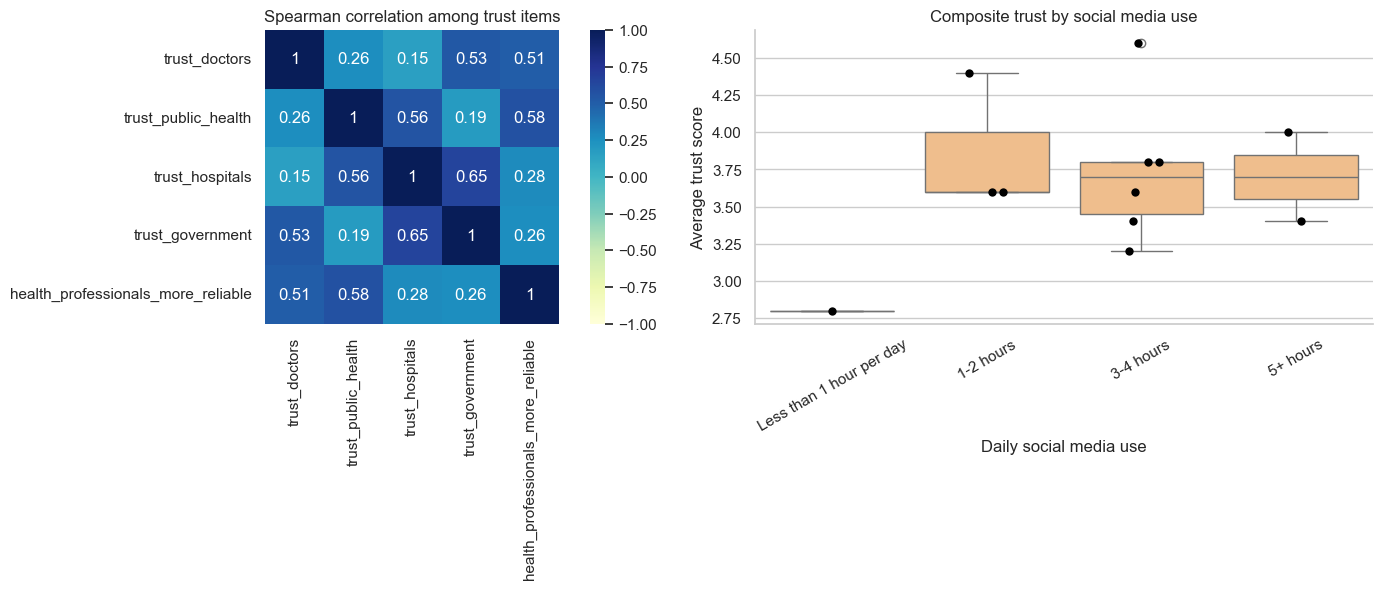

In [32]:
corr = analysis_df[trust_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr, annot=True, cmap="YlGnBu", vmin=-1, vmax=1, square=True, ax=axes[0])
axes[0].set_title("Spearman correlation among trust items")

available_order = [item for item in ["Less than 1 hour per day", "1-2 hours", "3-4 hours", "5+ hours"] if item in analysis_df["social_media_use"].unique()]
sns.boxplot(data=analysis_df, x="social_media_use", y="composite_trust", order=available_order, ax=axes[1], color="#FFBE7D")
sns.stripplot(data=analysis_df, x="social_media_use", y="composite_trust", order=available_order, ax=axes[1], color="black", size=6, jitter=0.12)
axes[1].set_title("Composite trust by social media use")
axes[1].set_xlabel("Daily social media use")
axes[1].set_ylabel("Average trust score")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Open-ended responses

A few respondents explained their views in their own words. The analysis below uses a simple keyword count to highlight the most common themes.

,word,count
0,microphone,1
1,skeptical,1
2,sells,1
3,influence,1
4,how,1
5,perceive,1
6,when,1
7,know,1
8,false,1
9,leads,1


,theme,mentions
0,misinformation / false content,2
1,skepticism / verification,5
2,influence / promotion,2


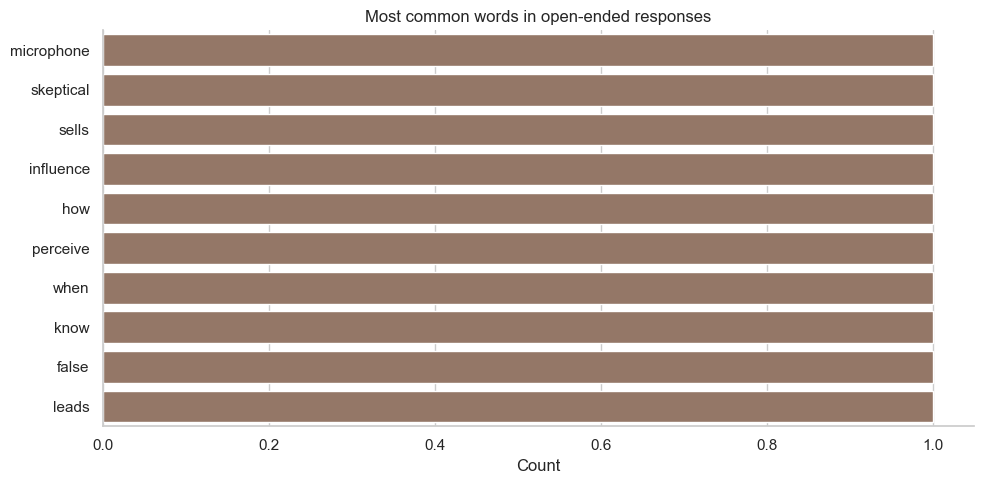

Sample open-ended responses:
- Social Media give a microphone to any famous person, regardless of their knowledge regarding health related subjects which makes me trust it less
- It doesn't. I always find myself very skeptical either way. 
- It often sells me things that influence how I perceive healthy things. When I see things I know are false, it leads to me trust it less. 
- I find that social media tend to spread misinformation which contributes to the mistrust
- I don't usually trust the health information that I see on social media, I verify before I consider the information I see online
- sometimes


In [33]:
stopwords = {
    "the", "and", "to", "of", "a", "it", "i", "is", "in", "on", "for", "me", "my",
    "with", "that", "this", "they", "as", "be", "are", "at", "from", "or", "an", "do", "not",
    "social", "media", "health", "information", "trust", "less", "more", "usually", "sometimes",
    "things", "see", "which", "find", "give", "any", "famous", "person", "regardless",
    "knowledge", "related", "subjects", "makes", "often", "don't", "dont", "doesn't", "doesnt",
    "using", "online", "healthy", "public", "content", "information", "consider", "before",
    "usually", "either", "their", "regarding", "always", "myself", "very", "way", "tend", "tends",
}

responses = analysis_df["free_text"].dropna().astype(str)
tokens = []
for response in responses:
    words = re.findall(r"[a-z']+", response.lower())
    tokens.extend([word for word in words if word not in stopwords and len(word) > 2])

word_counts = Counter(tokens)
top_words = pd.DataFrame(word_counts.most_common(10), columns=["word", "count"])
display(top_words)

theme_keywords = {
    "misinformation / false content": ["misinformation", "false", "fake", "mistrust"],
    "skepticism / verification": ["skeptical", "verify", "check", "consider", "trust"],
    "influence / promotion": ["influence", "sells", "microphone", "famous"],
}
theme_rows = []
for theme, keywords in theme_keywords.items():
    mentions = sum(any(keyword in response.lower() for keyword in keywords) for response in responses)
    theme_rows.append({"theme": theme, "mentions": mentions})

display(pd.DataFrame(theme_rows))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_words, x="count", y="word", ax=ax, color="#9C755F")
ax.set_title("Most common words in open-ended responses")
ax.set_xlabel("Count")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

print("Sample open-ended responses:")
for response in responses.tolist():
    print("-", response)

## Key takeaways

- Respondents reported heavy use of TikTok, Instagram, and YouTube, with health-related content appearing at least sometimes for most people.
- Trust was highest for doctors and other health professionals, while trust in government leadership was clearly lower.
- The open-ended responses repeatedly mentioned misinformation, skepticism, and verifying content before believing it.
- The sample is small, so these results should be read as exploratory patterns rather than generalizable conclusions.